# 72 - Human-vs-Silver-Label Agreement: Marmee's Self-Labeling Check

This notebook backs the "silver labels should be taken with a grain of salt" caveat Ralph asked to have stated explicitly in the thesis. Rather than checking Marmee against another human (that is notebook 73, vs. Kerem/Manav), this checks Marmee's own blind judgment against the existing LLM-judged silver labels.

The 300-candidate sample is stratified across 15 queries (5 industry-specific, 5 geographic, 5 functional), drawn only from queries with deep (70+) existing silver coverage, so every comparison is against a genuine LLM judgment rather than a lower-trust classifier-predicted bronze label. Labeling was blind: shuffled order, no rank or prior label shown, same guidelines given to the LLM judges and to Kerem/Manav.

This is a distinct comparison from notebook 73 and both should be cited together in the inter-annotator agreement section, alongside notebook 68's LLM-LLM and LLM-human numbers.

In [1]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.metrics import cohen_kappa_score, confusion_matrix

OUTPUT_DIR = Path("result/72_self_label_kappa_sample")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110

## Part 1: Load Marmee's blind labels and the hidden silver-label reference

Both files were generated together with a fixed row order, the assertion below guards against a silent misalignment before any metric is computed.

In [2]:
mine = pd.read_excel(OUTPUT_DIR / "self_label_kappa_sample.xlsx")
reference = pd.read_csv(OUTPUT_DIR / "REFERENCE_DO_NOT_OPEN_true_labels.csv")

assert (mine["domain"].values == reference["domain"].values).all(), "row order mismatch between blind file and reference, do not proceed with a mismatched comparison"

merged = mine.merge(reference, on=["query_id", "query", "domain"])
merged["relevance_label"] = merged["relevance_label"].astype(int)
merged["gold_label"] = merged["gold_label"].astype(int)

print(f"merged rows: {len(merged)}")
merged.head()

merged rows: 300


,query_id,query,domain,name,organization_type,country,summary,relevance_label,gold_label
0,72,managed service providers (MSPs),truepacket.com.my,True Packet Sdn Bhd,Company,Malaysia,True Packet Sdn Bhd is a Malaysian-based manag...,2,2
1,34,venture capital firms,consorcapital.com,Consor Capital LLC,Company,United States,Consor Capital LLC is a venture capital firm f...,2,2
2,12,manufacturing in Baden-Württemberg,bayer-raach.de,Bayer + Raach Neue Energien GmbH & Co. KG,Company,Germany,Bayer + Raach Neue Energien GmbH & Co. KG is a...,0,1
3,56,defense contractors,jmzqq.com,兵器工业集团,Company,China,China North Industries Group Corporation (Nori...,2,2
4,11,tech companies in Munich,biermeier.de,Bavarian Webdesign,Company,Germany,"Bavarian Webdesign, established in Munich in 2...",2,2


## Part 2: Headline agreement metrics

In [3]:
m = merged["relevance_label"]
g = merged["gold_label"]

exact_agreement = (m == g).mean()
kappa_3class = cohen_kappa_score(m, g)

m_bin = (m >= 1).astype(int)
g_bin = (g >= 1).astype(int)
kappa_binary = cohen_kappa_score(m_bin, g_bin)

print(f"exact row-level agreement: {(m == g).sum()}/{len(merged)} ({exact_agreement:.1%})")
print(f"Cohen's kappa (3-class, 0/1/2): {kappa_3class:.3f}")
print(f"Cohen's kappa (binary, relevant vs. not): {kappa_binary:.3f}")

exact row-level agreement: 236/300 (78.7%)
Cohen's kappa (3-class, 0/1/2): 0.603
Cohen's kappa (binary, relevant vs. not): 0.415


## Part 3: Per-query and per-stratum breakdown

15 queries, n=20 each, small enough per query that this is diagnostic rather than a headline figure on its own, useful for spotting whether disagreement concentrates in particular topics.

In [4]:
per_query_rows = []
for qid, group in merged.groupby("query_id"):
    gm = group["relevance_label"]
    gg = group["gold_label"]
    per_query_rows.append({
        "query_id": qid,
        "query": group["query"].iloc[0],
        "n": len(group),
        "exact_agreement": (gm == gg).mean(),
        "kappa_3class": cohen_kappa_score(gm, gg) if gg.nunique() > 1 and gm.nunique() > 1 else np.nan,
    })

per_query = pd.DataFrame(per_query_rows).sort_values("exact_agreement")
per_query

,query_id,query,n,exact_agreement,kappa_3class
5,11,tech companies in Munich,20,0.45,0.143969
6,12,manufacturing in Baden-Württemberg,20,0.55,0.250000
8,15,logistics companies in the US,20,0.55,0.237288
13,72,managed service providers (MSPs),20,0.60,0.384615
12,66,customer relationship management (CRM) software,20,0.75,0.390244
10,34,venture capital firms,20,0.80,0.615385
1,2,healthcare providers,20,0.80,0.652174
3,4,renewable energy companies in Germany,20,0.80,0.411765
9,27,biotech companies,20,0.85,0.733333
11,56,defense contractors,20,0.90,0.756098


## Part 4: Label distributions and confusion matrix

Unlike notebook 73's Kerem/Manav comparison (heavily skewed toward "highly relevant"), this sample's gold-label distribution is much more balanced (roughly 61% highly relevant, 30% partially relevant, 9% not relevant), so kappa here is less prone to the chance-correction distortion that required a caveat in notebook 73. Still worth reporting both raw agreement and kappa together for consistency.

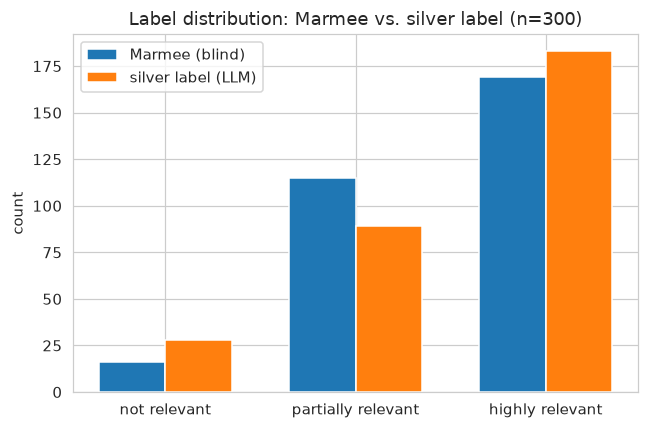

In [5]:
label_names = {0: "not relevant", 1: "partially relevant", 2: "highly relevant"}

dist_mine = m.value_counts().reindex([0, 1, 2], fill_value=0)
dist_gold = g.value_counts().reindex([0, 1, 2], fill_value=0)

fig, ax = plt.subplots(figsize=(6, 4))
x = np.arange(3)
width = 0.35
ax.bar(x - width / 2, dist_mine.values, width, label="Marmee (blind)")
ax.bar(x + width / 2, dist_gold.values, width, label="silver label (LLM)")
ax.set_xticks(x)
ax.set_xticklabels([label_names[i] for i in [0, 1, 2]])
ax.set_ylabel("count")
ax.set_title("Label distribution: Marmee vs. silver label (n=300)")
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "label_distribution_comparison.png")
plt.show()

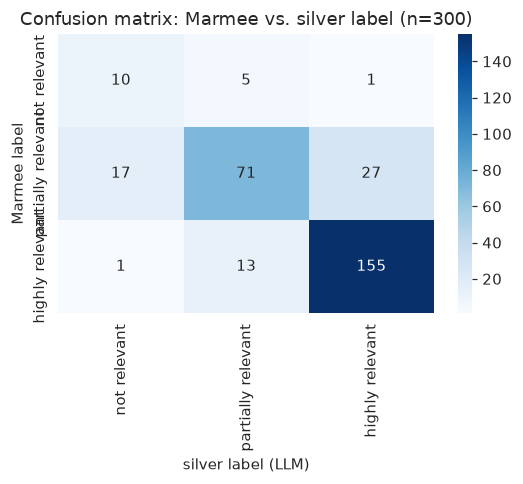

In [6]:
cm = confusion_matrix(m, g, labels=[0, 1, 2])

fig, ax = plt.subplots(figsize=(5, 4.5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=[label_names[i] for i in [0, 1, 2]], yticklabels=[label_names[i] for i in [0, 1, 2]], ax=ax)
ax.set_xlabel("silver label (LLM)")
ax.set_ylabel("Marmee label")
ax.set_title("Confusion matrix: Marmee vs. silver label (n=300)")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "confusion_matrix.png")
plt.show()

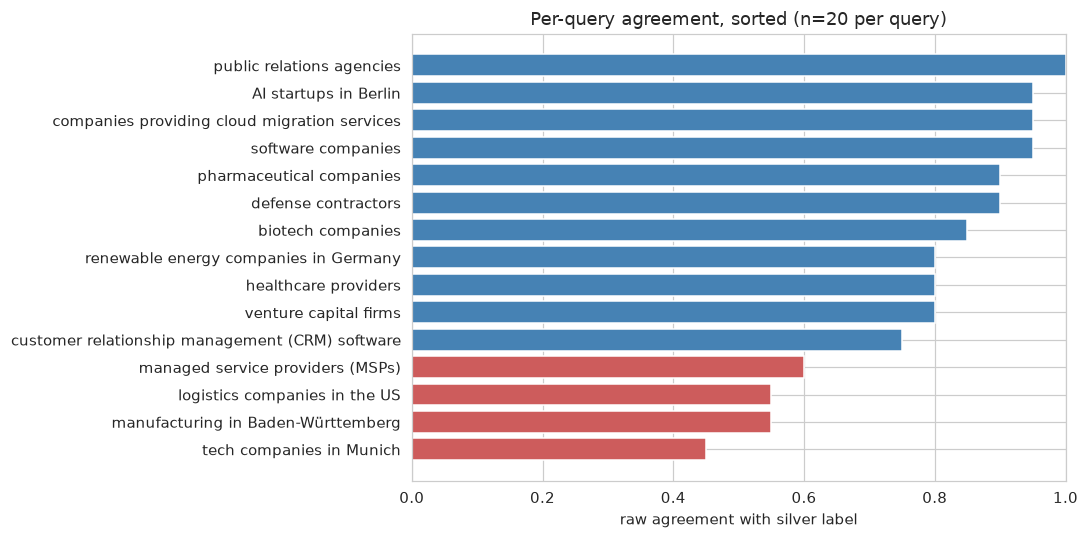

In [7]:
fig, ax = plt.subplots(figsize=(10, 5))
colors = ["indianred" if v < 0.7 else "steelblue" for v in per_query["exact_agreement"]]
ax.barh(per_query["query"], per_query["exact_agreement"], color=colors)
ax.set_xlabel("raw agreement with silver label")
ax.set_title("Per-query agreement, sorted (n=20 per query)")
ax.set_xlim(0, 1)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "per_query_agreement.png")
plt.show()

## Part 5: Disagreement cases

Qualitative look at where Marmee and the silver label diverge, useful for the "grain of salt" discussion, e.g. whether disagreements skew toward the silver label being too generous, too strict, or scattered without a clear direction.

In [8]:
disagreements = merged[merged["relevance_label"] != merged["gold_label"]].copy()
disagreements["direction"] = np.where(disagreements["relevance_label"] < disagreements["gold_label"], "Marmee stricter", "Marmee looser")

print(f"{len(disagreements)} disagreements out of {len(merged)} ({len(disagreements) / len(merged):.1%})")
print(disagreements["direction"].value_counts())

disagreements_out = disagreements[["query_id", "query", "domain", "name", "relevance_label", "gold_label", "direction"]]
disagreements_out.to_csv(OUTPUT_DIR / "disagreements.csv", index=False)
disagreements_out

64 disagreements out of 300 (21.3%)
direction
Marmee stricter    33
Marmee looser      31
Name: count, dtype: int64


,query_id,query,domain,name,relevance_label,gold_label,direction
2,12,manufacturing in Baden-Württemberg,bayer-raach.de,Bayer + Raach Neue Energien GmbH & Co. KG,0,1,Marmee stricter
14,5,companies providing cloud migration services,bizcloud9.com,Business Cloud Solutions,1,2,Marmee stricter
21,2,healthcare providers,yourbridgewell.com,BridgeWell,1,2,Marmee stricter
22,4,renewable energy companies in Germany,energiezukunftdeutschland.de,energiezukunftdeutschland.de,0,1,Marmee stricter
27,11,tech companies in Munich,ystmr.com,Yestermorrow Ventures UG (haftungsbeschränkt),1,2,Marmee stricter
...,...,...,...,...,...,...,...
287,56,defense contractors,meadconstruction.com,"Mead Construction, Inc.",2,1,Marmee looser
288,15,logistics companies in the US,viteusa.com,"ShenZhen ELONDA Information Technology Co., Ltd.",2,1,Marmee looser
290,34,venture capital firms,umbrahelion.com,Umbrahelion Corporation,1,2,Marmee stricter
294,11,tech companies in Munich,i-f-de.com,Innovations-Forum Deutschland,1,0,Marmee looser


## Summary for the thesis

In [9]:
summary = {
    "n": int(len(merged)),
    "exact_agreement": float(exact_agreement),
    "kappa_3class": float(kappa_3class),
    "kappa_binary": float(kappa_binary),
    "n_disagreements": int(len(disagreements)),
    "per_query": per_query.to_dict(orient="records"),
}

with open(OUTPUT_DIR / "summary_metrics.json", "w") as f:
    json.dump(summary, f, indent=2)

summary

{'n': 300,
 'exact_agreement': 0.7866666666666666,
 'kappa_3class': 0.6032238065716058,
 'kappa_binary': 0.4148244473342003,
 'n_disagreements': 64,
 'per_query': [{'query_id': 11,
   'query': 'tech companies in Munich',
   'n': 20,
   'exact_agreement': 0.45,
   'kappa_3class': 0.14396887159533067},
  {'query_id': 12,
   'query': 'manufacturing in Baden-Württemberg',
   'n': 20,
   'exact_agreement': 0.55,
   'kappa_3class': 0.25},
  {'query_id': 15,
   'query': 'logistics companies in the US',
   'n': 20,
   'exact_agreement': 0.55,
   'kappa_3class': 0.23728813559322037},
  {'query_id': 72,
   'query': 'managed service providers (MSPs)',
   'n': 20,
   'exact_agreement': 0.6,
   'kappa_3class': 0.3846153846153846},
  {'query_id': 66,
   'query': 'customer relationship management (CRM) software',
   'n': 20,
   'exact_agreement': 0.75,
   'kappa_3class': 0.3902439024390243},
  {'query_id': 34,
   'query': 'venture capital firms',
   'n': 20,
   'exact_agreement': 0.8,
   'kappa_3clas

### Notes for writing this up

- This is the number that backs the "silver labels should be taken with a grain of salt" caveat, report it in the limitations or methodology section next to that sentence, not buried elsewhere.
- Unlike notebook 73, this sample's label distribution is fairly balanced, so kappa and raw agreement should track each other reasonably well here, if they diverge sharply, say so and investigate rather than picking whichever number looks better.
- The per-query breakdown is useful for flagging whether specific query topics have systematically weaker silver labels, worth a sentence if 2-3 queries stand out as clear outliers.
- Cite this alongside notebook 73 (human-human, vs. Kerem/Manav) and notebook 68 (LLM-LLM, LLM-human) as the thesis's full inter-annotator agreement picture, three different comparisons, not interchangeable substitutes for each other.